In [49]:
import numpy as np
from math import log, sqrt, exp
from scipy.stats import norm


def black_scholes_call(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    """
    Black-Scholes closed-form price for a European call option.
    """
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)


def monte_carlo_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
    N: int,
    seed: int | None = None
) -> tuple[float, float]:
    """
    Monte Carlo pricing for a European call option under GBM.

    Returns
    -------
    price_estimate : float
        Estimated call price.
    std_error : float
        Standard error of the Monte Carlo estimator.
    """
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(ST - K, 0.0)

    discounted_payoffs = np.exp(-r * T) * payoffs
    price_estimate = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(N)

    return price_estimate, std_error


if __name__ == "__main__":
    S0 = 100
    K = 100
    r = 0.05
    sigma = 0.2
    T = 1.0

    bs_price = black_scholes_call(S0, K, r, sigma, T)

    for N in [10_000, 100_000, 1_000_000]:
        mc_price, se = monte_carlo_call(S0, K, r, sigma, T, N, seed=42)
        ci_low = mc_price - 1.96 * se
        ci_high = mc_price + 1.96 * se

        print(f"N = {N:,}")
        print(f"  Black-Scholes price : {bs_price:.6f}")
        print(f"  Monte Carlo price   : {mc_price:.6f}")
        print(f"  Std. Error          : {se:.6f}")
        print(f"  95% CI              : [{ci_low:.6f}, {ci_high:.6f}]")
        print(f"  Abs. Error          : {abs(mc_price - bs_price):.6f}")
        print()


N = 10,000
  Black-Scholes price : 10.450584
  Monte Carlo price   : 10.345182
  Std. Error          : 0.147663
  95% CI              : [10.055763, 10.634601]
  Abs. Error          : 0.105402

N = 100,000
  Black-Scholes price : 10.450584
  Monte Carlo price   : 10.420541
  Std. Error          : 0.046770
  95% CI              : [10.328872, 10.512210]
  Abs. Error          : 0.030042

N = 1,000,000
  Black-Scholes price : 10.450584
  Monte Carlo price   : 10.453195
  Std. Error          : 0.014731
  95% CI              : [10.424322, 10.482069]
  Abs. Error          : 0.002612



In [50]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple


@dataclass
class OptionParams:
    S0: float
    K: float
    r: float
    sigma: float
    T: float
    barrier: float | None = None


def simulate_gbm_path_from_increments(
    S0: float,
    r: float,
    sigma: float,
    T: float,
    dW: np.ndarray
) -> np.ndarray:
    """
    Simulate a GBM path from supplied Brownian increments.
    Returns path values including initial value S0.
    """
    n_steps = len(dW)
    h = T / n_steps
    path = np.empty(n_steps + 1, dtype=float)
    path[0] = S0

    drift = (r - 0.5 * sigma**2) * h
    for i in range(n_steps):
        path[i + 1] = path[i] * np.exp(drift + sigma * dW[i])

    return path


# ----------------------------
# Payoff functions
# ----------------------------

def european_call_payoff(path: np.ndarray, params: OptionParams) -> float:
    ST = path[-1]
    return np.exp(-params.r * params.T) * max(ST - params.K, 0.0)


def asian_call_payoff(path: np.ndarray, params: OptionParams) -> float:
    avg_price = np.mean(path[1:])  # or np.mean(path), depending on convention
    return np.exp(-params.r * params.T) * max(avg_price - params.K, 0.0)


def up_and_out_barrier_call_payoff(path: np.ndarray, params: OptionParams) -> float:
    if params.barrier is None:
        raise ValueError("Barrier level must be provided for barrier option.")
    if np.max(path) >= params.barrier:
        return 0.0
    ST = path[-1]
    return np.exp(-params.r * params.T) * max(ST - params.K, 0.0)


# ----------------------------
# Single MLMC sample
# ----------------------------

def mlmc_level_sample(
    level: int,
    params: OptionParams,
    payoff_fn: Callable[[np.ndarray, OptionParams], float],
    rng: np.random.Generator,
    M: int = 2
) -> float:
    """
    Generate one MLMC sample:
    - level 0 returns P0
    - level l>=1 returns Pl - P_{l-1}
    """
    if level == 0:
        n_coarse = 1
        h_coarse = params.T / n_coarse
        dW_coarse = rng.normal(loc=0.0, scale=np.sqrt(h_coarse), size=n_coarse)
        coarse_path = simulate_gbm_path_from_increments(
            params.S0, params.r, params.sigma, params.T, dW_coarse
        )
        return payoff_fn(coarse_path, params)

    n_fine = M**level
    n_coarse = M**(level - 1)

    h_fine = params.T / n_fine

    # Fine Brownian increments
    dW_fine = rng.normal(loc=0.0, scale=np.sqrt(h_fine), size=n_fine)

    # Coarse increments are sums of blocks of fine increments
    dW_coarse = dW_fine.reshape(n_coarse, M).sum(axis=1)

    fine_path = simulate_gbm_path_from_increments(
        params.S0, params.r, params.sigma, params.T, dW_fine
    )
    coarse_path = simulate_gbm_path_from_increments(
        params.S0, params.r, params.sigma, params.T, dW_coarse
    )

    payoff_fine = payoff_fn(fine_path, params)
    payoff_coarse = payoff_fn(coarse_path, params)

    return payoff_fine - payoff_coarse


# ----------------------------
# Estimate one level mean/variance
# ----------------------------

def estimate_level_statistics(
    level: int,
    n_samples: int,
    params: OptionParams,
    payoff_fn: Callable[[np.ndarray, OptionParams], float],
    rng: np.random.Generator,
    M: int = 2
) -> Tuple[float, float]:
    """
    Estimate sample mean and sample variance for one level.
    """
    samples = np.array([
        mlmc_level_sample(level, params, payoff_fn, rng, M)
        for _ in range(n_samples)
    ], dtype=float)

    mean = np.mean(samples)
    var = np.var(samples, ddof=1) if n_samples > 1 else 0.0
    return mean, var


# ----------------------------
# Basic fixed-allocation MLMC estimator
# ----------------------------

def mlmc_price_fixed_allocation(
    L: int,
    N_levels: List[int],
    params: OptionParams,
    payoff_fn: Callable[[np.ndarray, OptionParams], float],
    seed: int = 12345,
    M: int = 2
) -> Dict[str, object]:
    """
    Fixed-allocation MLMC estimator:
    Y = sum_{l=0}^L Y_l
    """
    if len(N_levels) != L + 1:
        raise ValueError("N_levels must have length L+1.")

    rng = np.random.default_rng(seed)

    level_means = []
    level_vars = []

    for level in range(L + 1):
        mean_l, var_l = estimate_level_statistics(
            level, N_levels[level], params, payoff_fn, rng, M
        )
        level_means.append(mean_l)
        level_vars.append(var_l)

    price_estimate = float(np.sum(level_means))
    std_error = float(np.sqrt(np.sum(np.array(level_vars) / np.array(N_levels))))

    return {
        "price": price_estimate,
        "std_error": std_error,
        "level_means": level_means,
        "level_vars": level_vars,
        "N_levels": N_levels,
    }


# ----------------------------
# Example usage
# ----------------------------

if __name__ == "__main__":
    params_eur = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0)
    params_asian = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0)
    params_barrier = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0, barrier=120)

    L = 4
    N_levels = [100000, 20000, 5000, 2000, 1000]

    res_eur = mlmc_price_fixed_allocation(L, N_levels, params_eur, european_call_payoff)
    res_asian = mlmc_price_fixed_allocation(L, N_levels, params_asian, asian_call_payoff)
    res_barrier = mlmc_price_fixed_allocation(L, N_levels, params_barrier, up_and_out_barrier_call_payoff)

    print("European MLMC:", res_eur)
    print("Asian MLMC:", res_asian)
    print("Barrier MLMC:", res_barrier)


European MLMC: {'price': 10.509485646144384, 'std_error': 0.04659155647106461, 'level_means': [np.float64(10.509485646144384), np.float64(4.265936562330985e-17), np.float64(2.0690792829070048e-16), np.float64(-2.4745483440113957e-16), np.float64(-2.698535839229521e-16)], 'level_vars': [np.float64(217.07731343964028), np.float64(1.0977162462803532e-28), np.float64(2.199896034480538e-28), np.float64(3.9823188520575836e-28), np.float64(8.446769601187823e-28)], 'N_levels': [100000, 20000, 5000, 2000, 1000]}
Asian MLMC: {'price': 6.251720167549787, 'std_error': 0.08132581521178851, 'level_means': [np.float64(10.509485646144384), np.float64(-2.299697998663606), np.float64(-1.1245662169815238), np.float64(-0.5531415403907329), np.float64(-0.28035972255873265)], 'level_vars': [np.float64(217.07731343964028), np.float64(31.671402957264608), np.float64(7.413446863122421), np.float64(1.7698089886989146), np.float64(0.49195107062839827)], 'N_levels': [100000, 20000, 5000, 2000, 1000]}
Barrier MLMC

In [51]:
import numpy as np
from dataclasses import dataclass
from typing import Dict


@dataclass
class OptionParams:
    S0: float
    K: float
    r: float
    sigma: float
    T: float
    barrier: float | None = None


# ----------------------------
# Batch payoff computation
# ----------------------------

def european_call_payoffs_batch(
    params: OptionParams,
    n_steps: int,
    batch_size: int,
    rng: np.random.Generator
) -> np.ndarray:
    """
    European call payoff for one batch.
    For European option under GBM, only terminal value is needed.
    """
    h = params.T / n_steps
    Z = rng.standard_normal((batch_size, n_steps))
    dW = np.sqrt(h) * Z

    log_ST = np.sum((params.r - 0.5 * params.sigma**2) * h + params.sigma * dW, axis=1)
    ST = params.S0 * np.exp(log_ST)

    payoffs = np.exp(-params.r * params.T) * np.maximum(ST - params.K, 0.0)
    return payoffs


def asian_call_payoffs_batch(
    params: OptionParams,
    n_steps: int,
    batch_size: int,
    rng: np.random.Generator
) -> np.ndarray:
    """
    Arithmetic Asian call payoff for one batch.
    Memory-safe: only store current batch paths.
    """
    h = params.T / n_steps
    Z = rng.standard_normal((batch_size, n_steps))
    dW = np.sqrt(h) * Z

    increments = (params.r - 0.5 * params.sigma**2) * h + params.sigma * dW

    # build path batch
    log_paths = np.cumsum(increments, axis=1)
    paths = params.S0 * np.exp(log_paths)

    # average over monitoring dates excluding S0
    avg_price = np.mean(paths, axis=1)

    payoffs = np.exp(-params.r * params.T) * np.maximum(avg_price - params.K, 0.0)
    return payoffs


def up_and_out_barrier_call_payoffs_batch(
    params: OptionParams,
    n_steps: int,
    batch_size: int,
    rng: np.random.Generator
) -> np.ndarray:
    """
    Discretely monitored up-and-out barrier call payoff for one batch.
    """
    if params.barrier is None:
        raise ValueError("Barrier level must be provided for barrier option.")

    h = params.T / n_steps
    Z = rng.standard_normal((batch_size, n_steps))
    dW = np.sqrt(h) * Z

    increments = (params.r - 0.5 * params.sigma**2) * h + params.sigma * dW
    log_paths = np.cumsum(increments, axis=1)
    paths = params.S0 * np.exp(log_paths)

    path_max = np.max(paths, axis=1)
    ST = paths[:, -1]

    payoffs = np.exp(-params.r * params.T) * np.maximum(ST - params.K, 0.0)
    payoffs[path_max >= params.barrier] = 0.0
    return payoffs


# ----------------------------
# Batch benchmark driver
# ----------------------------

def reference_benchmark_mc_batched(
    params: OptionParams,
    payoff_batch_fn,
    n_steps: int,
    n_paths: int,
    batch_size: int = 2000,
    seed: int = 12345,
    verbose: bool = True
) -> Dict[str, float]:
    """
    High-accuracy Monte Carlo benchmark using batching to avoid RAM overflow.
    """
    rng = np.random.default_rng(seed)

    total_sum = 0.0
    total_sum_sq = 0.0
    total_count = 0

    batch_id = 0
    while total_count < n_paths:
        current_batch = min(batch_size, n_paths - total_count)

        payoffs = payoff_batch_fn(
            params=params,
            n_steps=n_steps,
            batch_size=current_batch,
            rng=rng
        )

        total_sum += float(np.sum(payoffs))
        total_sum_sq += float(np.sum(payoffs**2))
        total_count += current_batch
        batch_id += 1

        if verbose and (batch_id % 20 == 0 or total_count == n_paths):
            print(f"Processed {total_count:,} / {n_paths:,} paths")

    price = total_sum / total_count

    # unbiased sample variance
    sample_var = (total_sum_sq - total_count * price**2) / (total_count - 1)
    std_error = np.sqrt(sample_var / total_count)

    ci_low = price - 1.96 * std_error
    ci_high = price + 1.96 * std_error

    return {
        "price": float(price),
        "std_error": float(std_error),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "n_steps": int(n_steps),
        "n_paths": int(n_paths),
        "batch_size": int(batch_size),
    }


In [52]:
params_eur = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0)

eur_ref = reference_benchmark_mc_batched(
    params=params_eur,
    payoff_batch_fn=european_call_payoffs_batch,
    n_steps=1,
    n_paths=500_000,
    batch_size=10_000,
    seed=123,
    verbose=True
)

print("European reference:", eur_ref)


Processed 200,000 / 500,000 paths
Processed 400,000 / 500,000 paths
Processed 500,000 / 500,000 paths
European reference: {'price': 10.449641123522238, 'std_error': 0.02080143515005095, 'ci_low': 10.408870310628137, 'ci_high': 10.490411936416338, 'n_steps': 1, 'n_paths': 500000, 'batch_size': 10000}


In [53]:
params_asian = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0)

asian_ref = reference_benchmark_mc_batched(
    params=params_asian,
    payoff_batch_fn=asian_call_payoffs_batch,
    n_steps=2048,
    n_paths=200_000,
    batch_size=1000,
    seed=123,
    verbose=True
)

print("Asian reference:", asian_ref)


Processed 20,000 / 200,000 paths
Processed 40,000 / 200,000 paths
Processed 60,000 / 200,000 paths
Processed 80,000 / 200,000 paths
Processed 100,000 / 200,000 paths
Processed 120,000 / 200,000 paths
Processed 140,000 / 200,000 paths
Processed 160,000 / 200,000 paths
Processed 180,000 / 200,000 paths
Processed 200,000 / 200,000 paths
Asian reference: {'price': 5.786042151744203, 'std_error': 0.017845826745706228, 'ci_low': 5.751064331322619, 'ci_high': 5.821019972165788, 'n_steps': 2048, 'n_paths': 200000, 'batch_size': 1000}


In [54]:
params_barrier = OptionParams(S0=100, K=100, r=0.05, sigma=0.2, T=1.0, barrier=120)

barrier_ref = reference_benchmark_mc_batched(
    params=params_barrier,
    payoff_batch_fn=up_and_out_barrier_call_payoffs_batch,
    n_steps=4096,
    n_paths=200_000,
    batch_size=500,
    seed=123,
    verbose=True
)

print("Barrier reference:", barrier_ref)


Processed 10,000 / 200,000 paths
Processed 20,000 / 200,000 paths
Processed 30,000 / 200,000 paths
Processed 40,000 / 200,000 paths
Processed 50,000 / 200,000 paths
Processed 60,000 / 200,000 paths
Processed 70,000 / 200,000 paths
Processed 80,000 / 200,000 paths
Processed 90,000 / 200,000 paths
Processed 100,000 / 200,000 paths
Processed 110,000 / 200,000 paths
Processed 120,000 / 200,000 paths
Processed 130,000 / 200,000 paths
Processed 140,000 / 200,000 paths
Processed 150,000 / 200,000 paths
Processed 160,000 / 200,000 paths
Processed 170,000 / 200,000 paths
Processed 180,000 / 200,000 paths
Processed 190,000 / 200,000 paths
Processed 200,000 / 200,000 paths
Barrier reference: {'price': 1.2103039423109088, 'std_error': 0.0072059358463928014, 'ci_low': 1.1961803080519788, 'ci_high': 1.2244275765698387, 'n_steps': 4096, 'n_paths': 200000, 'batch_size': 500}


In [55]:
def compare_to_reference(method_price: float, ref_price: float):
    abs_error = abs(method_price - ref_price)
    rel_error = abs_error / abs(ref_price) if ref_price != 0 else np.nan
    return {
        "method_price": method_price,
        "reference_price": ref_price,
        "abs_error": abs_error,
        "rel_error": rel_error,
    }

eur_cmp = compare_to_reference(res_eur["price"], eur_ref["price"])
asian_cmp = compare_to_reference(res_asian["price"], asian_ref["price"])
barrier_cmp = compare_to_reference(res_barrier["price"], barrier_ref["price"])

print("European comparison:", eur_cmp)
print("Asian comparison:", asian_cmp)
print("Barrier comparison:", barrier_cmp)


European comparison: {'method_price': 10.509485646144384, 'reference_price': 10.449641123522238, 'abs_error': 0.05984452262214646, 'rel_error': 0.005726945252448516}
Asian comparison: {'method_price': 6.251720167549787, 'reference_price': 5.786042151744203, 'abs_error': 0.465678015805584, 'rel_error': 0.08048299746057075}
Barrier comparison: {'method_price': 1.8650276771248346, 'reference_price': 1.2103039423109088, 'abs_error': 0.6547237348139259, 'rel_error': 0.540958111368142}


# Reproducing Giles (2008) Multilevel Monte Carlo

This section is added after the existing exploratory code. The goal is to reproduce the MLMC workflow in Michael B. Giles, *Multilevel Monte Carlo Path Simulation* (Operations Research, 2008), using the same model setup and numerical choices used in the paper's geometric Brownian motion experiments.

## Paper Setup

Giles considers geometric Brownian motion

$$
dS = rS\,dt + \sigma S\,dW, \qquad 0 < t < 1,
$$

with

$$
S(0)=1, \qquad r=0.05, \qquad \sigma=0.2, \qquad T=1.
$$

The paper uses Euler discretisation directly on $S$:

$$
\widehat S_{n+1}=\widehat S_n + r\widehat S_n h + \sigma \widehat S_n \Delta W_n.
$$

This is important. The earlier code in this notebook simulates GBM through the exact lognormal update. That is useful for option pricing, but it removes the Euler discretisation bias that Giles is studying. For the reproduction below, we therefore use the Euler update.

## Payoffs to Reproduce First

The first two GBM examples in the paper are:

European call:

$$
P = e^{-rT}\max(0, S(T)-1).
$$

Asian call:

$$
P = e^{-rT}\max(0, \bar S - 1), \qquad \bar S = \int_0^1 S(t)\,dt.
$$

The Asian integral is discretised using the trapezoidal rule, consistent with the paper:

$$
\bar S_l \approx \sum_{n=1}^{M^l} \frac{1}{2}\left(\widehat S_n + \widehat S_{n-1}\right) h_l.
$$

## MLMC Identity

For level $l$, let $P_l$ be the payoff computed with timestep

$$
h_l = T M^{-l}.
$$

Giles uses a telescoping sum:

$$
E[P_L] = E[P_0] + \sum_{l=1}^L E[P_l - P_{l-1}].
$$

Each term is estimated separately:

$$
\widehat Y = \sum_{l=0}^L \widehat Y_l.
$$

For $l=0$, samples are $P_0$. For $l>0$, samples are coupled differences $P_l-P_{l-1}$.

## Coupled Fine-Coarse Simulation

For a level $l>0$ sample:

1. Generate fine Brownian increments using $M^l$ timesteps.
2. Sum every $M$ fine increments to form the coarse Brownian increments.
3. Simulate the fine path with timestep $h_l$.
4. Simulate the coarse path with timestep $h_{l-1}$.
5. Return $P_l-P_{l-1}$.

This coupling is the variance reduction mechanism. As $l$ increases, $P_l$ and $P_{l-1}$ become very close, so the variance of $P_l-P_{l-1}$ decreases.

## Giles Numerical Choices

For the GBM numerical experiments in the paper:

- refinement factor: $M=4$
- initial samples for estimating each new level variance: $10^4$
- European and Asian accuracy targets shown in the figures:

$$
\varepsilon \in \{5\times 10^{-5}, 10^{-4}, 2\times 10^{-4}, 5\times 10^{-4}, 10^{-3}\}.
$$

The code below keeps these values as the default reproduction settings.

## Adaptive Sample Allocation

After estimating the level variance $V_l$, Giles chooses approximately optimal sample counts using

$$
N_l = \left\lceil 2\varepsilon^{-2}\sqrt{V_l h_l}\sum_{k=0}^L \sqrt{V_k/h_k}\right\rceil.
$$

This makes the MLMC estimator variance approximately less than $\varepsilon^2/2$, leaving the other half of the error budget for bias.

## Bias Stopping Rule

Without Richardson extrapolation, the paper uses the correction on the finest levels to decide whether the bias is small enough:

$$
\max\left(M^{-1}|\widehat Y_{L-1}|, |\widehat Y_L|\right)
< \frac{1}{\sqrt{2}}(M-1)\varepsilon.
$$

The implementation below follows this heuristic stopping rule. Because this is a heuristic, the notebook also reports diagnostics: level means, variances, sample counts, and total cost.


In [56]:
import numpy as np
from dataclasses import dataclass
from math import ceil, exp, sqrt
from typing import Callable, Dict, List


@dataclass(frozen=True)
class GilesGBMParams:
    S0: float = 1.0
    K: float = 1.0
    r: float = 0.05
    sigma: float = 0.2
    T: float = 1.0


GILES_PARAMS = GilesGBMParams()
GILES_M = 4
GILES_EPSILONS = [5e-5, 1e-4, 2e-4, 5e-4, 1e-3]
GILES_INITIAL_SAMPLES = 10_000


def euler_gbm_path_from_increments(
    dW: np.ndarray,
    params: GilesGBMParams = GILES_PARAMS,
) -> np.ndarray:
    """Euler discretisation used in Giles (2008), not the exact lognormal GBM update."""
    n_steps = len(dW)
    h = params.T / n_steps
    path = np.empty(n_steps + 1, dtype=float)
    path[0] = params.S0

    for n in range(n_steps):
        s = path[n]
        path[n + 1] = s + params.r * s * h + params.sigma * s * dW[n]

    return path


def giles_european_call_payoff(path: np.ndarray, params: GilesGBMParams = GILES_PARAMS) -> float:
    return exp(-params.r * params.T) * max(path[-1] - params.K, 0.0)


def giles_asian_call_payoff(path: np.ndarray, params: GilesGBMParams = GILES_PARAMS) -> float:
    n_steps = len(path) - 1
    h = params.T / n_steps
    average = np.sum(0.5 * (path[1:] + path[:-1]) * h) / params.T
    return exp(-params.r * params.T) * max(average - params.K, 0.0)


def giles_level_sample(
    level: int,
    payoff_fn: Callable[[np.ndarray, GilesGBMParams], float],
    rng: np.random.Generator,
    params: GilesGBMParams = GILES_PARAMS,
    M: int = GILES_M,
) -> float:
    """One MLMC sample: P0 at level 0, or coupled Pl - P_{l-1} for level > 0."""
    if level == 0:
        n_steps = 1
        h = params.T / n_steps
        dW = rng.normal(0.0, sqrt(h), size=n_steps)
        path = euler_gbm_path_from_increments(dW, params)
        return payoff_fn(path, params)

    n_fine = M**level
    n_coarse = M ** (level - 1)
    h_fine = params.T / n_fine

    dW_fine = rng.normal(0.0, sqrt(h_fine), size=n_fine)
    dW_coarse = dW_fine.reshape(n_coarse, M).sum(axis=1)

    fine_path = euler_gbm_path_from_increments(dW_fine, params)
    coarse_path = euler_gbm_path_from_increments(dW_coarse, params)

    return payoff_fn(fine_path, params) - payoff_fn(coarse_path, params)


def sample_level_values(
    level: int,
    n_samples: int,
    payoff_fn: Callable[[np.ndarray, GilesGBMParams], float],
    rng: np.random.Generator,
    params: GilesGBMParams = GILES_PARAMS,
    M: int = GILES_M,
) -> np.ndarray:
    return np.array(
        [giles_level_sample(level, payoff_fn, rng, params=params, M=M) for _ in range(n_samples)],
        dtype=float,
    )


def giles_level_cost(level: int, M: int = GILES_M) -> int:
    if level == 0:
        return 1
    return M**level + M ** (level - 1)


def giles_mlmc_adaptive(
    eps: float,
    payoff_fn: Callable[[np.ndarray, GilesGBMParams], float],
    params: GilesGBMParams = GILES_PARAMS,
    M: int = GILES_M,
    initial_samples: int = GILES_INITIAL_SAMPLES,
    seed: int = 12345,
    max_level: int = 8,
) -> Dict[str, object]:
    """Adaptive MLMC algorithm following Giles (2008), Section 5."""
    rng = np.random.default_rng(seed)

    sums: List[float] = []
    sums_sq: List[float] = []
    n_done: List[int] = []
    level_means: List[float] = []
    level_vars: List[float] = []

    L = 0
    converged = False

    while not converged:
        while len(n_done) <= L:
            values = sample_level_values(L, initial_samples, payoff_fn, rng, params=params, M=M)
            sums.append(float(values.sum()))
            sums_sq.append(float(np.dot(values, values)))
            n_done.append(initial_samples)
            level_means.append(float(values.mean()))
            level_vars.append(float(values.var(ddof=1)))

        h_levels = np.array([params.T / (M**l) for l in range(L + 1)], dtype=float)
        variances = np.maximum(np.array(level_vars[: L + 1], dtype=float), 1e-16)

        allocation_factor = np.sum(np.sqrt(variances / h_levels))
        n_opt = np.ceil(2.0 * eps**-2 * np.sqrt(variances * h_levels) * allocation_factor).astype(int)
        n_opt = np.maximum(n_opt, initial_samples)

        for level in range(L + 1):
            extra = int(n_opt[level] - n_done[level])
            if extra > 0:
                values = sample_level_values(level, extra, payoff_fn, rng, params=params, M=M)
                sums[level] += float(values.sum())
                sums_sq[level] += float(np.dot(values, values))
                n_done[level] += extra

                mean = sums[level] / n_done[level]
                var = (sums_sq[level] - n_done[level] * mean**2) / max(n_done[level] - 1, 1)
                level_means[level] = float(mean)
                level_vars[level] = float(max(var, 0.0))

        if L >= 2:
            bias_indicator = max(abs(level_means[L - 1]) / M, abs(level_means[L]))
            bias_tolerance = (M - 1) * eps / sqrt(2.0)
            converged = bias_indicator < bias_tolerance
        else:
            bias_indicator = np.inf
            bias_tolerance = (M - 1) * eps / sqrt(2.0)

        if not converged:
            if L >= max_level:
                break
            L += 1

    n_array = np.array(n_done[: L + 1], dtype=int)
    means = np.array(level_means[: L + 1], dtype=float)
    vars_ = np.array(level_vars[: L + 1], dtype=float)
    costs = np.array([giles_level_cost(l, M=M) for l in range(L + 1)], dtype=int)

    price = float(means.sum())
    variance = float(np.sum(vars_ / n_array))
    total_cost = int(np.sum(n_array * costs))

    return {
        "eps": eps,
        "price": price,
        "std_error": sqrt(variance),
        "variance": variance,
        "L": L,
        "M": M,
        "N_l": n_array.tolist(),
        "level_means": means.tolist(),
        "level_vars": vars_.tolist(),
        "level_costs": costs.tolist(),
        "total_cost": total_cost,
        "eps2_cost": eps**2 * total_cost,
        "bias_indicator": float(bias_indicator),
        "bias_tolerance": float(bias_tolerance),
        "converged": bool(converged),
    }


In [ ]:
# European call reproduction using the paper's GBM data and eps values.
# This can be computationally expensive because it follows the paper's 10^4 initial samples per level.
european_results = [
    giles_mlmc_adaptive(eps, giles_european_call_payoff, seed=12345)
    for eps in GILES_EPSILONS
]

for result in european_results:
    print(
        f"eps={result['eps']:.0e} | price={result['price']:.8f} | "
        f"se={result['std_error']:.3e} | L={result['L']} | "
        f"cost={result['total_cost']:,} | eps^2 cost={result['eps2_cost']:.4g} | "
        f"converged={result['converged']}"
    )
    print("  N_l:", result["N_l"])
    print("  means:", [f"{x:.3e}" for x in result["level_means"]])
    print("  vars :", [f"{x:.3e}" for x in result["level_vars"]])


In [ ]:
# Asian call reproduction using the paper's GBM data, trapezoidal average, M=4, and eps values.
asian_results = [
    giles_mlmc_adaptive(eps, giles_asian_call_payoff, seed=54321)
    for eps in GILES_EPSILONS
]

for result in asian_results:
    print(
        f"eps={result['eps']:.0e} | price={result['price']:.8f} | "
        f"se={result['std_error']:.3e} | L={result['L']} | "
        f"cost={result['total_cost']:,} | eps^2 cost={result['eps2_cost']:.4g} | "
        f"converged={result['converged']}"
    )
    print("  N_l:", result["N_l"])
    print("  means:", [f"{x:.3e}" for x in result["level_means"]])
    print("  vars :", [f"{x:.3e}" for x in result["level_vars"]])


eps=5e-05 | price=0.05758671 | se=3.534e-05 | L=4 | cost=58,125,086 | eps^2 cost=0.1453 | converged=True
  N_l: [12561686, 3945404, 590499, 96818, 19628]
  means: ['5.100e-02', '6.060e-03', '4.621e-04', '7.136e-05', '-9.477e-06']
  vars : ['4.025e-03', '1.589e-03', '1.424e-04', '1.529e-05', '2.491e-06']
eps=1e-04 | price=0.05758084 | se=7.073e-05 | L=3 | cost=11,584,880 | eps^2 cost=0.1158 | converged=True
  N_l: [2811490, 884482, 131617, 21483]
  means: ['5.095e-02', '6.074e-03', '5.008e-04', '5.361e-05']
  vars : ['4.020e-03', '1.592e-03', '1.410e-04', '1.507e-05']
eps=2e-04 | price=0.05726960 | se=1.368e-04 | L=3 | cost=3,244,206 | eps^2 cost=0.1298 | converged=True
  N_l: [698846, 219460, 32403, 10000]
  means: ['5.072e-02', '6.066e-03', '4.286e-04', '5.576e-05']
  vars : ['4.000e-03', '1.583e-03', '1.382e-04', '1.507e-05']
eps=5e-04 | price=0.05750009 | se=3.106e-04 | L=3 | cost=1,287,849 | eps^2 cost=0.322 | converged=True
  N_l: [112239, 35122, 10000, 10000]
  means: ['5.081e-02

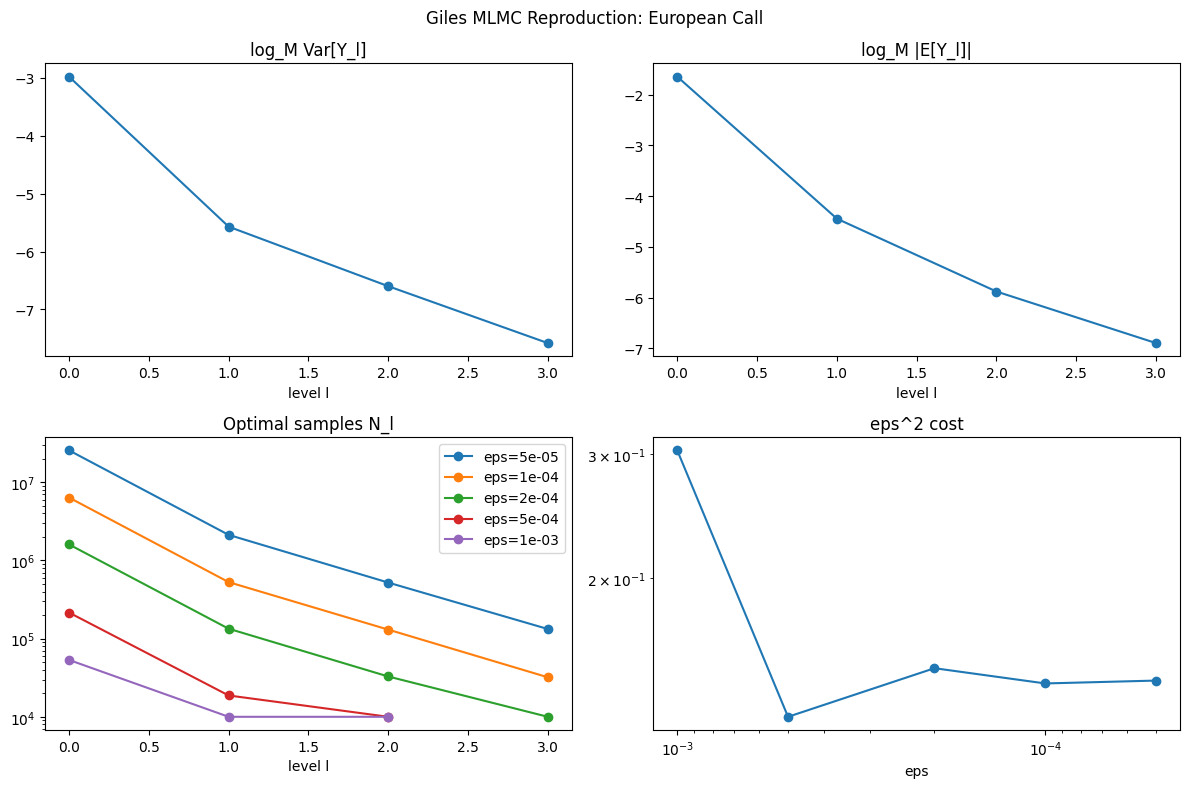

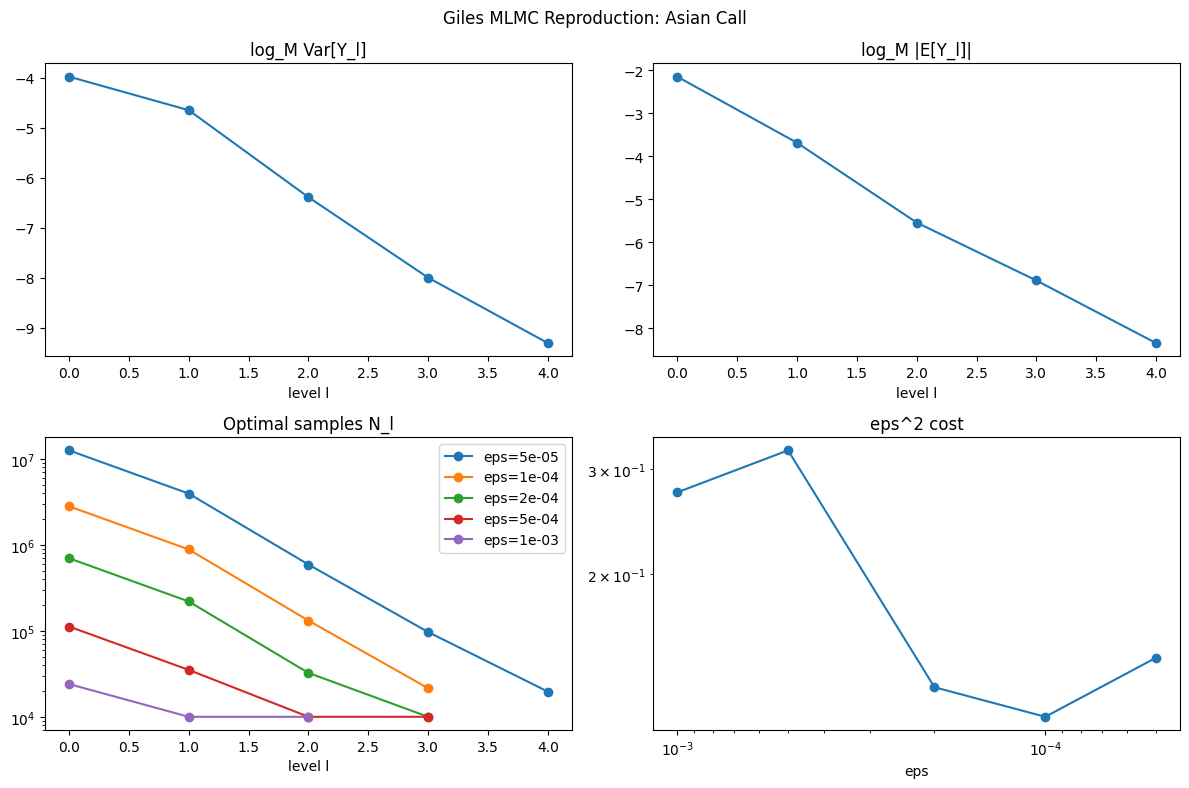

In [ ]:
import matplotlib.pyplot as plt


def plot_giles_diagnostics(results: List[Dict[str, object]], title: str) -> None:
    finest = results[0]
    levels = np.arange(finest["L"] + 1)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title)

    axes[0, 0].plot(levels, np.log(np.maximum(finest["level_vars"], 1e-300)) / np.log(finest["M"]), marker="o")
    axes[0, 0].set_title("log_M Var[Y_l]")
    axes[0, 0].set_xlabel("level l")

    axes[0, 1].plot(levels, np.log(np.maximum(np.abs(finest["level_means"]), 1e-300)) / np.log(finest["M"]), marker="o")
    axes[0, 1].set_title("log_M |E[Y_l]|")
    axes[0, 1].set_xlabel("level l")

    for result in results:
        axes[1, 0].plot(np.arange(result["L"] + 1), result["N_l"], marker="o", label=f"eps={result['eps']:.0e}")
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_title("Optimal samples N_l")
    axes[1, 0].set_xlabel("level l")
    axes[1, 0].legend()

    eps = np.array([r["eps"] for r in results])
    eps2_cost = np.array([r["eps2_cost"] for r in results])
    axes[1, 1].loglog(eps, eps2_cost, marker="o")
    axes[1, 1].invert_xaxis()
    axes[1, 1].set_title("eps^2 cost")
    axes[1, 1].set_xlabel("eps")

    plt.tight_layout()
    plt.show()


plot_giles_diagnostics(european_results, "Giles MLMC Reproduction: European Call")
plot_giles_diagnostics(asian_results, "Giles MLMC Reproduction: Asian Call")


# Modified MLMC: Iterative Variance-Stabilized Allocation

The original Giles MLMC algorithm already uses adaptive sample allocation: it estimates the level variances $V_l$, computes approximately optimal sample counts $N_l$, adds the missing samples, and then checks whether the finest-level bias indicator is small enough.

Our proposed modification focuses on the finite-sample weakness of this procedure. A small pilot estimate of $V_l$ can be noisy, especially for path-dependent or nonsmooth payoffs. If the algorithm immediately jumps to the full estimated $N_l$, it may oversample levels whose variance was overestimated, or undersample levels whose variance was underestimated.

The modified method below uses an iterative variance-stabilized allocation rule.

## Motivation

Giles' target allocation is

$$
N_l = \left\lceil 2\varepsilon^{-2}\sqrt{V_l h_l}\sum_{k=0}^L \sqrt{V_k/h_k}\right\rceil.
$$

This formula is optimal only if the estimated $V_l$ values are reliable. In practice, early variance estimates can change noticeably after additional samples are added.

Our modification therefore avoids jumping directly to the full target allocation. Instead, it repeatedly:

1. estimates $V_l$ from the samples currently available,
2. computes the current target allocation $N_l^{target}$,
3. adds only a controlled fraction of the missing samples,
4. updates $V_l$ and $N_l^{target}$,
5. stops the allocation loop only when the target allocation stabilizes.

## Algorithm

For a fixed maximum level $L$:

1. Start each new level with a pilot sample size $n_0$.
2. Estimate level means and variances.
3. Compute $N_l^{target}$ using the Giles allocation formula.
4. For each level, let

$$
\Delta_l = \max(0, N_l^{target} - N_l^{current}).
$$

5. Instead of adding all $\Delta_l$ samples, add

$$
\min\left(\lceil \theta \Delta_l \rceil, \text{batch cap}\right),
$$

where $0 < \theta \le 1$ is a damping factor.

6. Recompute variances and repeat until either:
   - the relative change in target allocation is below a tolerance, or
   - the current sample counts have reached the target allocation, or
   - a maximum number of allocation rounds is reached.

7. Apply the same Giles bias stopping rule:

$$
\max\left(M^{-1}|\widehat Y_{L-1}|, |\widehat Y_L|\right)
< \frac{1}{\sqrt{2}}(M-1)\varepsilon.
$$

If the bias check fails, add a new level and repeat.

## Research Hypothesis

This modified allocation may reduce practical computational cost by avoiding overreaction to noisy pilot variance estimates. The expected benefit should be more visible for path-dependent payoffs, such as the Asian option, than for the simpler European option.

This is not claimed as a new theoretical complexity result. It is a practical finite-sample modification to be evaluated empirically against the original Giles MLMC algorithm.


In [ ]:
def giles_mlmc_iterative_modified(
    eps: float,
    payoff_fn: Callable[[np.ndarray, GilesGBMParams], float],
    params: GilesGBMParams = GILES_PARAMS,
    M: int = GILES_M,
    pilot_samples: int = 2_000,
    min_samples: int = 2_000,
    damping: float = 0.5,
    batch_cap: int = 50_000,
    allocation_tol: float = 0.05,
    max_allocation_rounds: int = 8,
    seed: int = 24680,
    max_level: int = 8,
) -> Dict[str, object]:
    """Modified MLMC with iterative variance-stabilized sample allocation.

    This keeps the same MLMC estimator and Giles bias rule, but changes how
    samples are added after estimating level variances. Instead of immediately
    jumping to the current optimal N_l, it adds a damped and capped number of
    samples, then recomputes variances and allocations.
    """
    if not (0.0 < damping <= 1.0):
        raise ValueError("damping must be in (0, 1].")
    if pilot_samples <= 1:
        raise ValueError("pilot_samples must be greater than 1.")
    if min_samples <= 1:
        raise ValueError("min_samples must be greater than 1.")

    rng = np.random.default_rng(seed)

    sums: List[float] = []
    sums_sq: List[float] = []
    n_done: List[int] = []
    level_means: List[float] = []
    level_vars: List[float] = []
    allocation_rounds_by_L: List[int] = []
    target_history_by_L: List[List[List[int]]] = []

    def add_samples(level: int, n_samples: int) -> None:
        values = sample_level_values(level, n_samples, payoff_fn, rng, params=params, M=M)
        if level == len(n_done):
            sums.append(float(values.sum()))
            sums_sq.append(float(np.dot(values, values)))
            n_done.append(n_samples)
        else:
            sums[level] += float(values.sum())
            sums_sq[level] += float(np.dot(values, values))
            n_done[level] += n_samples

        mean = sums[level] / n_done[level]
        var = (sums_sq[level] - n_done[level] * mean**2) / max(n_done[level] - 1, 1)
        var = max(float(var), 0.0)

        if level == len(level_means):
            level_means.append(float(mean))
            level_vars.append(var)
        else:
            level_means[level] = float(mean)
            level_vars[level] = var

    def compute_targets(L: int) -> np.ndarray:
        h_levels = np.array([params.T / (M**l) for l in range(L + 1)], dtype=float)
        variances = np.maximum(np.array(level_vars[: L + 1], dtype=float), 1e-16)
        allocation_factor = np.sum(np.sqrt(variances / h_levels))
        targets = np.ceil(2.0 * eps**-2 * np.sqrt(variances * h_levels) * allocation_factor).astype(int)
        return np.maximum(targets, min_samples)

    L = 0
    converged = False

    while not converged:
        while len(n_done) <= L:
            add_samples(len(n_done), pilot_samples)

        previous_targets = None
        target_history: List[List[int]] = []
        rounds_used = 0

        for round_idx in range(max_allocation_rounds):
            targets = compute_targets(L)
            target_history.append(targets.tolist())
            rounds_used = round_idx + 1

            if previous_targets is None:
                allocation_stable = False
            else:
                denom = np.maximum(previous_targets, 1)
                relative_change = np.max(np.abs(targets - previous_targets) / denom)
                allocation_stable = bool(relative_change < allocation_tol)

            current_n = np.array(n_done[: L + 1], dtype=int)
            deficits = np.maximum(targets - current_n, 0)
            reached_targets = bool(np.all(deficits == 0))
            relative_deficit = np.max(deficits / np.maximum(targets, 1))
            nearly_reached_targets = bool(relative_deficit < allocation_tol)

            if reached_targets or (allocation_stable and nearly_reached_targets):
                break

            for level, deficit in enumerate(deficits):
                if deficit <= 0:
                    continue
                n_add = int(min(batch_cap, max(1, ceil(damping * int(deficit)))))
                add_samples(level, n_add)

            previous_targets = targets

        allocation_rounds_by_L.append(rounds_used)
        target_history_by_L.append(target_history)

        if L >= 2:
            bias_indicator = max(abs(level_means[L - 1]) / M, abs(level_means[L]))
            bias_tolerance = (M - 1) * eps / sqrt(2.0)
            converged = bias_indicator < bias_tolerance
        else:
            bias_indicator = np.inf
            bias_tolerance = (M - 1) * eps / sqrt(2.0)

        if not converged:
            if L >= max_level:
                break
            L += 1

    n_array = np.array(n_done[: L + 1], dtype=int)
    means = np.array(level_means[: L + 1], dtype=float)
    vars_ = np.array(level_vars[: L + 1], dtype=float)
    costs = np.array([giles_level_cost(l, M=M) for l in range(L + 1)], dtype=int)

    price = float(means.sum())
    variance = float(np.sum(vars_ / n_array))
    total_cost = int(np.sum(n_array * costs))

    return {
        "eps": eps,
        "price": price,
        "std_error": sqrt(variance),
        "variance": variance,
        "L": L,
        "M": M,
        "N_l": n_array.tolist(),
        "level_means": means.tolist(),
        "level_vars": vars_.tolist(),
        "level_costs": costs.tolist(),
        "total_cost": total_cost,
        "eps2_cost": eps**2 * total_cost,
        "bias_indicator": float(bias_indicator),
        "bias_tolerance": float(bias_tolerance),
        "converged": bool(converged),
        "pilot_samples": pilot_samples,
        "min_samples": min_samples,
        "damping": damping,
        "batch_cap": batch_cap,
        "allocation_tol": allocation_tol,
        "max_allocation_rounds": max_allocation_rounds,
        "allocation_rounds_by_L": allocation_rounds_by_L,
        "target_history_by_L": target_history_by_L,
    }


# Run Modified MLMC Experiments

This section runs the modified iterative variance-stabilized MLMC algorithm. We first run a small smoke test to confirm that the implementation works, then run the modified method on the same European and Asian payoff functions used in the Giles reproduction section.

The full paper-level eps list can be computationally expensive. For development, it is useful to start with a smaller test list such as:

```python
MODIFIED_TEST_EPSILONS = [1e-3, 5e-4]
```

After confirming the code works, switch to:

```python
GILES_EPSILONS = [5e-5, 1e-4, 2e-4, 5e-4, 1e-3]
```

The modified method reports the same main quantities as the original Giles MLMC implementation:

- estimated price
- standard error
- final level `L`
- level sample counts `N_l`
- level means and variances
- total computational cost
- `eps^2 * cost`
- allocation rounds used at each level expansion


In [ ]:
# Quick smoke test for the modified MLMC implementation.
# This uses a relaxed eps so it should finish much faster than the full paper-level experiment.
modified_smoke_european = giles_mlmc_iterative_modified(
    eps=1e-3,
    payoff_fn=giles_european_call_payoff,
    pilot_samples=1_000,
    min_samples=1_000,
    damping=0.5,
    batch_cap=20_000,
    max_allocation_rounds=5,
    seed=24680,
    max_level=6,
)

modified_smoke_asian = giles_mlmc_iterative_modified(
    eps=1e-3,
    payoff_fn=giles_asian_call_payoff,
    pilot_samples=1_000,
    min_samples=1_000,
    damping=0.5,
    batch_cap=20_000,
    max_allocation_rounds=5,
    seed=13579,
    max_level=6,
)

for name, result in [
    ("European", modified_smoke_european),
    ("Asian", modified_smoke_asian),
]:
    print(f"{name} modified MLMC smoke test")
    print(
        f"  eps={result['eps']:.0e} | price={result['price']:.8f} | "
        f"se={result['std_error']:.3e} | L={result['L']} | "
        f"cost={result['total_cost']:,} | eps^2 cost={result['eps2_cost']:.4g} | "
        f"converged={result['converged']}"
    )
    print("  N_l:", result["N_l"])
    print("  means:", [f"{x:.3e}" for x in result["level_means"]])
    print("  vars :", [f"{x:.3e}" for x in result["level_vars"]])
    print("  allocation rounds by L:", result["allocation_rounds_by_L"])
    print()


European modified MLMC smoke test
  eps=1e-03 | price=0.10343537 | se=7.146e-04 | L=2 | cost=91,315 | eps^2 cost=0.09131 | converged=True
  N_l: [51135, 3944, 1023]
  means: ['1.016e-01', '1.664e-03', '1.249e-04']
  vars : ['1.617e-02', '3.861e-04', '9.877e-05']
  allocation rounds by L: [5, 5, 4]

Asian modified MLMC smoke test
  eps=1e-03 | price=0.05878447 | se=7.157e-04 | L=2 | cost=83,385 | eps^2 cost=0.08339 | converged=True
  N_l: [23875, 7434, 1117]
  means: ['5.167e-02', '6.129e-03', '9.837e-04']
  vars : ['4.116e-03', '1.588e-03', '1.410e-04']
  allocation rounds by L: [5, 5, 4]



In [ ]:
# Modified MLMC experiments on the same eps list used in the Giles reproduction.
# For faster iteration, replace GILES_EPSILONS with MODIFIED_TEST_EPSILONS.
MODIFIED_TEST_EPSILONS = [1e-3, 5e-4]
# MODIFIED_EPSILONS_TO_RUN = MODIFIED_TEST_EPSILONS
MODIFIED_EPSILONS_TO_RUN = GILES_EPSILONS

modified_european_results = [
    giles_mlmc_iterative_modified(
        eps=eps,
        payoff_fn=giles_european_call_payoff,
        pilot_samples=2_000,
        min_samples=2_000,
        damping=0.5,
        batch_cap=50_000,
        allocation_tol=0.05,
        max_allocation_rounds=8,
        seed=24680,
        max_level=8,
    )
    for eps in MODIFIED_EPSILONS_TO_RUN
]

modified_asian_results = [
    giles_mlmc_iterative_modified(
        eps=eps,
        payoff_fn=giles_asian_call_payoff,
        pilot_samples=2_000,
        min_samples=2_000,
        damping=0.5,
        batch_cap=50_000,
        allocation_tol=0.05,
        max_allocation_rounds=8,
        seed=13579,
        max_level=8,
    )
    for eps in MODIFIED_EPSILONS_TO_RUN
]

for label, results in [
    ("European", modified_european_results),
    ("Asian", modified_asian_results),
]:
    print(f"Modified MLMC results: {label}")
    for result in results:
        print(
            f"eps={result['eps']:.0e} | price={result['price']:.8f} | "
            f"se={result['std_error']:.3e} | L={result['L']} | "
            f"cost={result['total_cost']:,} | eps^2 cost={result['eps2_cost']:.4g} | "
            f"converged={result['converged']}"
        )
        print("  N_l:", result["N_l"])
        print("  allocation rounds by L:", result["allocation_rounds_by_L"])
    print()


Modified MLMC results: European
eps=5e-05 | price=0.10462186 | se=1.042e-04 | L=3 | cost=28,482,960 | eps^2 cost=0.07121 | converged=True
  N_l: [1602000, 1202000, 519456, 131023]
  allocation rounds by L: [8, 8, 8, 8]
eps=1e-04 | price=0.10456273 | se=1.120e-04 | L=3 | cost=9,483,745 | eps^2 cost=0.09484 | converged=True
  N_l: [1602000, 530253, 130424, 32775]
  allocation rounds by L: [8, 8, 8, 8]
eps=2e-04 | price=0.10450475 | se=1.426e-04 | L=3 | cost=3,501,367 | eps^2 cost=0.1401 | converged=True
  N_l: [1548337, 133346, 31939, 8094]
  allocation rounds by L: [8, 8, 8, 8]
eps=5e-04 | price=0.10427076 | se=3.565e-04 | L=2 | cost=381,652 | eps^2 cost=0.09541 | converged=True
  N_l: [210567, 17253, 4241]
  allocation rounds by L: [6, 6, 5]
eps=1e-03 | price=0.10341554 | se=6.826e-04 | L=2 | cost=112,835 | eps^2 cost=0.1128 | converged=True
  N_l: [51450, 4277, 2000]
  allocation rounds by L: [6, 4, 4]

Modified MLMC results: Asian
eps=5e-05 | price=0.05768329 | se=5.943e-05 | L=4 | c

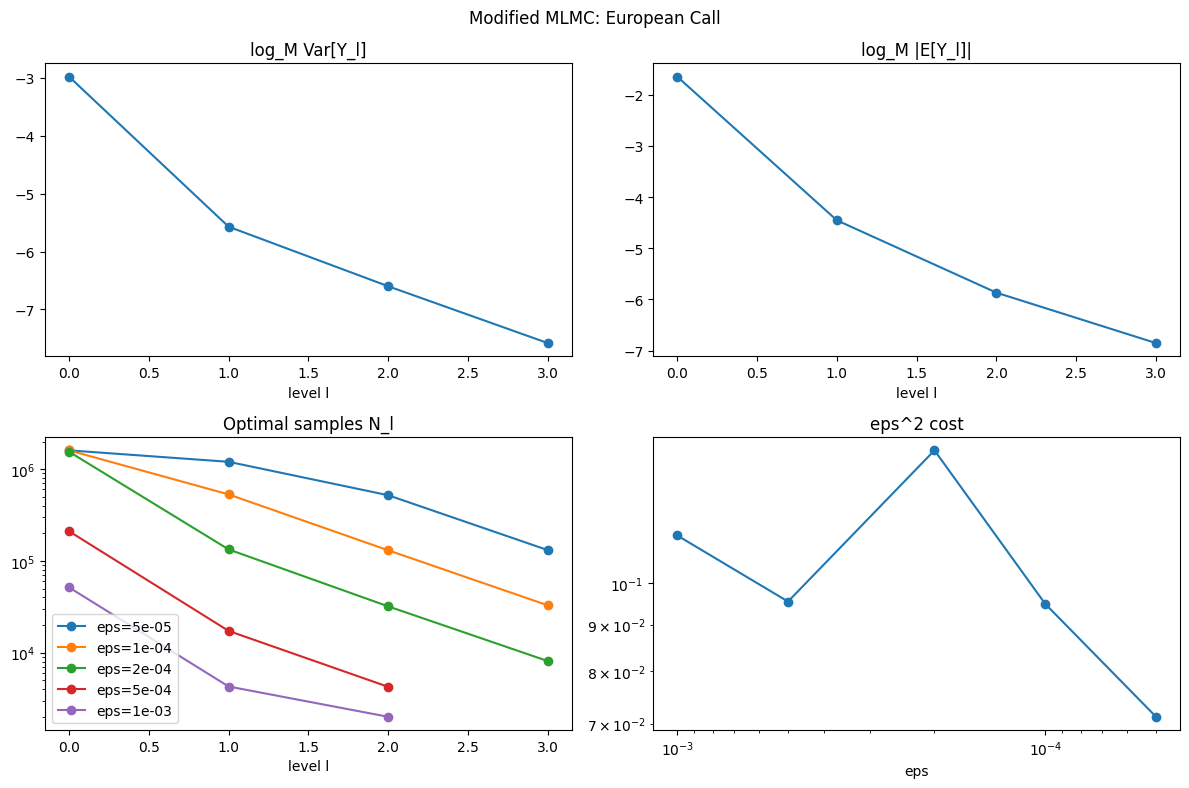

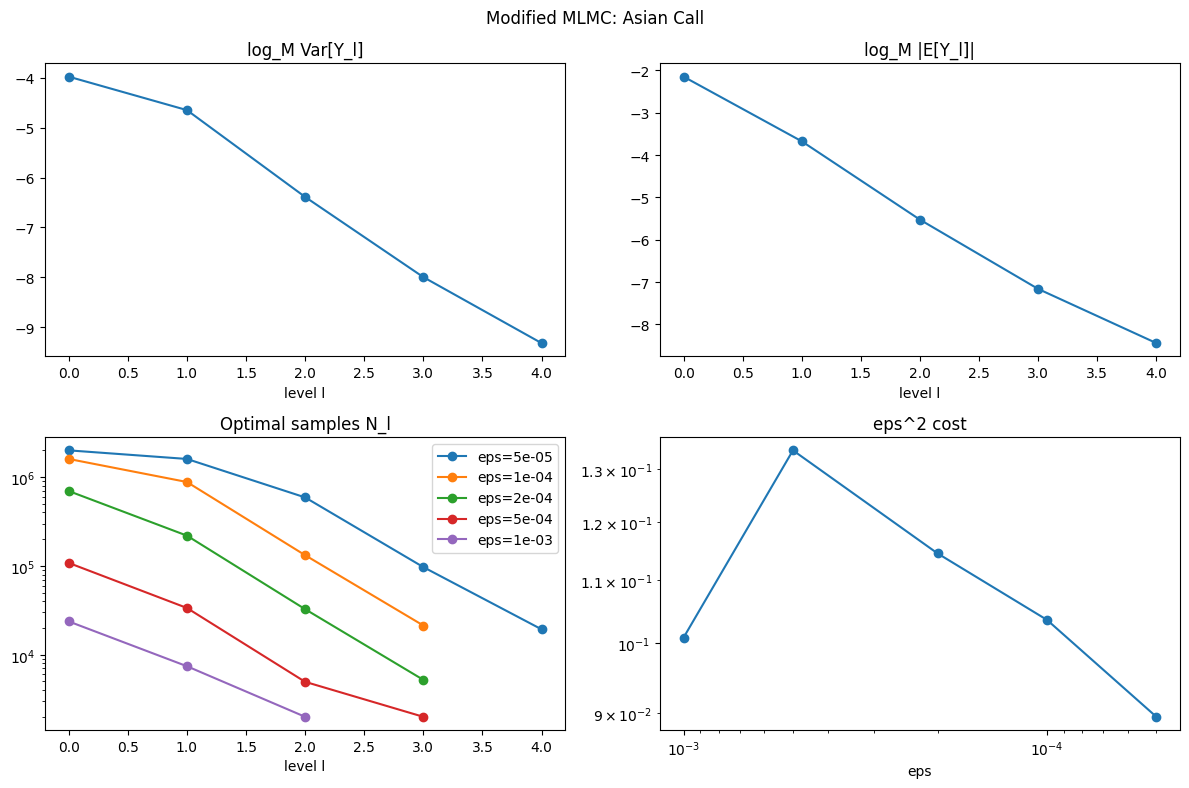

In [ ]:
# Diagnostic plots for the modified MLMC runs.
plot_giles_diagnostics(modified_european_results, "Modified MLMC: European Call")
plot_giles_diagnostics(modified_asian_results, "Modified MLMC: Asian Call")


# Final Experiment Framework and Evaluation

This section closes the loop with the project proposal. The proposal requires a comparison of standard Monte Carlo, original Giles MLMC, and our modified MLMC method in terms of accuracy, variance/RMSE, runtime, computational cost, and level-by-level sample allocation.

## Goals

The remaining work is organized around seven tasks:

1. Build a unified comparison framework.
2. Record runtime for each method.
3. Estimate RMSE using repeated runs.
4. Use fair reference prices under the same model and payoff definitions.
5. Add standard Monte Carlo for the Asian option.
6. Produce final comparison plots.
7. Write conclusion analysis answering the proposal's research question.

## Experimental Objects

We compare two options:

- European call: $e^{-rT}\max(S_T-K,0)$
- Arithmetic Asian call: $e^{-rT}\max(\bar S-K,0)$, where $\bar S$ is computed with the same trapezoidal rule used in the Giles reproduction section.

We compare three methods:

- Standard MC with Euler discretization
- Original Giles MLMC
- Modified iterative variance-stabilized MLMC

## Fair References

For the European call, we use the Black-Scholes closed-form price with the Giles parameters:

$$
S_0=1,\quad K=1,\quad r=0.05,\quad \sigma=0.2,\quad T=1.
$$

For the Asian call, there is no simple closed-form benchmark. We therefore estimate a high-accuracy reference using standard Monte Carlo on a very fine Euler grid with the same trapezoidal Asian payoff definition.

## Standard MC Design

Standard MC uses a pilot sample to estimate payoff variance. Given target accuracy $\varepsilon$, it chooses the target sample count

$$
N \approx \left\lceil \frac{2V}{\varepsilon^2}\right\rceil,
$$

so that the sampling variance is approximately below $\varepsilon^2/2$.

The standard MC cost is measured as

$$
\text{cost} = N \times \text{number of timesteps}.
$$

## RMSE Design

For repeated runs, RMSE is computed as

$$
\text{RMSE}=\sqrt{\frac{1}{R}\sum_{i=1}^R (\widehat P_i-P_{ref})^2}.
$$

The framework also reports a single-run RMSE proxy:

$$
\sqrt{(\widehat P-P_{ref})^2 + \widehat{SE}^2}.
$$

The repeated-run RMSE is more meaningful for the final report, while the proxy is useful during development.

## Recommended Workflow

For development, use a small experiment:

```python
FINAL_TEST_EPSILONS = [1e-3, 5e-4]
FINAL_TEST_REPS = 3
```

For the final report, increase to:

```python
FINAL_EPSILONS = GILES_EPSILONS
FINAL_REPS = 5  # or 10 if runtime is acceptable
```

The final analysis should answer:

> Does the iterative variance-stabilized allocation reduce practical computational cost compared with original Giles MLMC while maintaining comparable accuracy?


In [ ]:
import time
from math import log

try:
    import pandas as pd
except ImportError:
    pd = None


OPTION_LABELS = {
    "european": "European Call",
    "asian": "Asian Call",
}


def giles_black_scholes_reference(params: GilesGBMParams = GILES_PARAMS) -> float:
    return black_scholes_call(params.S0, params.K, params.r, params.sigma, params.T)


def euler_payoffs_batch(
    option: str,
    n_steps: int,
    n_paths: int,
    rng: np.random.Generator,
    params: GilesGBMParams = GILES_PARAMS,
) -> np.ndarray:
    """Vectorized Euler payoffs for European or Asian options under Giles parameters."""
    h = params.T / n_steps
    sqrt_h = sqrt(h)
    s = np.full(n_paths, params.S0, dtype=float)

    if option == "asian":
        integral = np.zeros(n_paths, dtype=float)

    for _ in range(n_steps):
        s_prev = s
        dW = rng.normal(0.0, sqrt_h, size=n_paths)
        s = s_prev + params.r * s_prev * h + params.sigma * s_prev * dW
        if option == "asian":
            integral += 0.5 * (s_prev + s) * h

    if option == "european":
        raw = np.maximum(s - params.K, 0.0)
    elif option == "asian":
        average = integral / params.T
        raw = np.maximum(average - params.K, 0.0)
    else:
        raise ValueError(f"Unknown option: {option}")

    return np.exp(-params.r * params.T) * raw


def mc_payoff_summary_batched(
    option: str,
    n_steps: int,
    n_paths: int,
    batch_size: int = 10_000,
    seed: int = 12345,
    params: GilesGBMParams = GILES_PARAMS,
) -> Dict[str, float]:
    """Mean and standard error for Euler standard MC using batches."""
    rng = np.random.default_rng(seed)
    total_sum = 0.0
    total_sum_sq = 0.0
    total_count = 0

    while total_count < n_paths:
        current = min(batch_size, n_paths - total_count)
        payoffs = euler_payoffs_batch(option, n_steps, current, rng, params=params)
        total_sum += float(np.sum(payoffs))
        total_sum_sq += float(np.dot(payoffs, payoffs))
        total_count += current

    mean = total_sum / total_count
    var = (total_sum_sq - total_count * mean**2) / max(total_count - 1, 1)
    var = max(var, 0.0)
    return {
        "price": float(mean),
        "std_error": float(sqrt(var / total_count)),
        "sample_var": float(var),
        "n_paths": int(total_count),
        "n_steps": int(n_steps),
        "cost": int(total_count * n_steps),
    }


def estimate_asian_reference(
    n_steps: int = 4096,
    n_paths: int = 200_000,
    batch_size: int = 2_000,
    seed: int = 98765,
    params: GilesGBMParams = GILES_PARAMS,
) -> Dict[str, float]:
    """High-accuracy Asian reference under the same Euler/trapezoidal definition."""
    start = time.perf_counter()
    result = mc_payoff_summary_batched(
        option="asian",
        n_steps=n_steps,
        n_paths=n_paths,
        batch_size=batch_size,
        seed=seed,
        params=params,
    )
    result["runtime"] = time.perf_counter() - start
    result["reference_type"] = "fine-grid Euler MC"
    return result


def build_reference_prices(
    asian_n_steps: int = 4096,
    asian_n_paths: int = 200_000,
    asian_batch_size: int = 2_000,
    params: GilesGBMParams = GILES_PARAMS,
) -> Dict[str, Dict[str, float]]:
    european_price = giles_black_scholes_reference(params)
    asian_ref = estimate_asian_reference(
        n_steps=asian_n_steps,
        n_paths=asian_n_paths,
        batch_size=asian_batch_size,
        params=params,
    )
    return {
        "european": {
            "price": float(european_price),
            "std_error": 0.0,
            "reference_type": "Black-Scholes closed form",
        },
        "asian": asian_ref,
    }


In [ ]:
def standard_mc_n_steps_for_eps(eps: float, M: int = GILES_M, min_level: int = 2, max_level: int = 8) -> int:
    """Choose a fine Euler grid for standard MC, roughly matching the MLMC bias scale."""
    level = int(np.ceil(np.log(1.0 / eps) / np.log(M)))
    level = min(max(level, min_level), max_level)
    return M**level


def run_standard_mc_experiment(
    option: str,
    eps: float,
    reference_price: float,
    params: GilesGBMParams = GILES_PARAMS,
    pilot_paths: int = 5_000,
    batch_size: int = 10_000,
    seed: int = 11111,
    n_steps: int | None = None,
) -> Dict[str, object]:
    """Adaptive standard MC using pilot variance to choose N."""
    if n_steps is None:
        n_steps = standard_mc_n_steps_for_eps(eps)

    start = time.perf_counter()
    pilot = mc_payoff_summary_batched(
        option=option,
        n_steps=n_steps,
        n_paths=pilot_paths,
        batch_size=batch_size,
        seed=seed,
        params=params,
    )
    target_paths = int(max(pilot_paths, ceil(2.0 * pilot["sample_var"] / eps**2)))
    result = mc_payoff_summary_batched(
        option=option,
        n_steps=n_steps,
        n_paths=target_paths,
        batch_size=batch_size,
        seed=seed + 1,
        params=params,
    )
    runtime = time.perf_counter() - start

    price = result["price"]
    abs_error = abs(price - reference_price)
    return {
        "method": "Standard MC",
        "option": OPTION_LABELS[option],
        "option_key": option,
        "eps": eps,
        "price": price,
        "reference": reference_price,
        "abs_error": abs_error,
        "std_error": result["std_error"],
        "rmse_proxy": float(sqrt(abs_error**2 + result["std_error"]**2)),
        "runtime": runtime,
        "cost": result["cost"],
        "L": None,
        "N_l": [result["n_paths"]],
        "n_paths": result["n_paths"],
        "n_steps": result["n_steps"],
        "converged": True,
    }


def normalize_mlmc_result(
    raw: Dict[str, object],
    method: str,
    option: str,
    reference_price: float,
    runtime: float,
) -> Dict[str, object]:
    price = float(raw["price"])
    std_error = float(raw["std_error"])
    abs_error = abs(price - reference_price)
    return {
        "method": method,
        "option": OPTION_LABELS[option],
        "option_key": option,
        "eps": float(raw["eps"]),
        "price": price,
        "reference": reference_price,
        "abs_error": abs_error,
        "std_error": std_error,
        "rmse_proxy": float(sqrt(abs_error**2 + std_error**2)),
        "runtime": runtime,
        "cost": int(raw["total_cost"]),
        "L": int(raw["L"]),
        "N_l": raw["N_l"],
        "n_paths": int(sum(raw["N_l"])),
        "n_steps": None,
        "converged": bool(raw["converged"]),
        "level_means": raw["level_means"],
        "level_vars": raw["level_vars"],
    }


def run_giles_mlmc_experiment(
    option: str,
    eps: float,
    reference_price: float,
    seed: int = 22222,
) -> Dict[str, object]:
    payoff_fn = giles_european_call_payoff if option == "european" else giles_asian_call_payoff
    start = time.perf_counter()
    raw = giles_mlmc_adaptive(eps, payoff_fn, seed=seed)
    runtime = time.perf_counter() - start
    return normalize_mlmc_result(raw, "Original Giles MLMC", option, reference_price, runtime)


def run_modified_mlmc_experiment(
    option: str,
    eps: float,
    reference_price: float,
    seed: int = 33333,
) -> Dict[str, object]:
    payoff_fn = giles_european_call_payoff if option == "european" else giles_asian_call_payoff
    start = time.perf_counter()
    raw = giles_mlmc_iterative_modified(
        eps=eps,
        payoff_fn=payoff_fn,
        pilot_samples=2_000,
        min_samples=2_000,
        damping=0.5,
        batch_cap=50_000,
        allocation_tol=0.05,
        max_allocation_rounds=8,
        seed=seed,
        max_level=8,
    )
    runtime = time.perf_counter() - start
    result = normalize_mlmc_result(raw, "Modified MLMC", option, reference_price, runtime)
    result["allocation_rounds_by_L"] = raw["allocation_rounds_by_L"]
    return result


In [ ]:
def run_single_comparison(
    eps_values: List[float],
    references: Dict[str, Dict[str, float]],
    options: List[str] | None = None,
    include_standard_mc: bool = True,
    include_giles_mlmc: bool = True,
    include_modified_mlmc: bool = True,
    base_seed: int = 1000,
) -> List[Dict[str, object]]:
    """Run one comparison pass across options, eps values, and selected methods."""
    if options is None:
        options = ["european", "asian"]

    rows: List[Dict[str, object]] = []
    for option in options:
        reference_price = references[option]["price"]
        for eps_idx, eps in enumerate(eps_values):
            seed = base_seed + 10_000 * eps_idx
            if include_standard_mc:
                rows.append(run_standard_mc_experiment(option, eps, reference_price, seed=seed + 1))
            if include_giles_mlmc:
                rows.append(run_giles_mlmc_experiment(option, eps, reference_price, seed=seed + 2))
            if include_modified_mlmc:
                rows.append(run_modified_mlmc_experiment(option, eps, reference_price, seed=seed + 3))
    return rows


def run_repeated_comparison(
    eps_values: List[float],
    references: Dict[str, Dict[str, float]],
    reps: int = 3,
    options: List[str] | None = None,
) -> List[Dict[str, object]]:
    """Run repeated experiments and attach replicate ids for RMSE aggregation."""
    all_rows: List[Dict[str, object]] = []
    for rep in range(reps):
        rows = run_single_comparison(
            eps_values=eps_values,
            references=references,
            options=options,
            base_seed=1000 + 100_000 * rep,
        )
        for row in rows:
            row["rep"] = rep
        all_rows.extend(rows)
    return all_rows


def rows_to_dataframe(rows: List[Dict[str, object]]):
    if pd is None:
        print("pandas is not installed; returning raw rows.")
        return rows
    return pd.DataFrame(rows)


def summarize_rmse(rows: List[Dict[str, object]]):
    """Aggregate repeated runs into RMSE/cost/runtime summary."""
    if pd is None:
        summary = []
        keys = sorted({(r["method"], r["option"], r["eps"]) for r in rows})
        for method, option, eps in keys:
            group = [r for r in rows if (r["method"], r["option"], r["eps"]) == (method, option, eps)]
            errors = np.array([r["price"] - r["reference"] for r in group], dtype=float)
            summary.append({
                "method": method,
                "option": option,
                "eps": eps,
                "rmse": float(np.sqrt(np.mean(errors**2))),
                "mean_cost": float(np.mean([r["cost"] for r in group])),
                "mean_runtime": float(np.mean([r["runtime"] for r in group])),
                "mean_price": float(np.mean([r["price"] for r in group])),
                "mean_std_error": float(np.mean([r["std_error"] for r in group])),
            })
        return summary

    df = pd.DataFrame(rows).copy()
    df["sq_error"] = (df["price"] - df["reference"]) ** 2
    summary = (
        df.groupby(["method", "option", "eps"], as_index=False)
        .agg(
            rmse=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
            mean_cost=("cost", "mean"),
            mean_runtime=("runtime", "mean"),
            mean_price=("price", "mean"),
            mean_std_error=("std_error", "mean"),
            mean_abs_error=("abs_error", "mean"),
        )
    )
    return summary


In [ ]:
def plot_final_comparisons(summary) -> None:
    """Final report plots: cost, runtime, RMSE, and eps^2 cost."""
    if pd is None:
        print("Install pandas to use plot_final_comparisons with grouped summaries.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for option, option_df in summary.groupby("option"):
        for method, method_df in option_df.groupby("method"):
            ordered = method_df.sort_values("eps")
            label = f"{option} - {method}"
            axes[0, 0].loglog(ordered["eps"], ordered["mean_cost"], marker="o", label=label)
            axes[0, 1].loglog(ordered["eps"], ordered["mean_runtime"], marker="o", label=label)
            axes[1, 0].loglog(ordered["eps"], ordered["rmse"], marker="o", label=label)
            axes[1, 1].loglog(ordered["eps"], ordered["eps"] ** 2 * ordered["mean_cost"], marker="o", label=label)

    axes[0, 0].set_title("Cost vs eps")
    axes[0, 0].set_xlabel("eps")
    axes[0, 0].set_ylabel("mean cost")

    axes[0, 1].set_title("Runtime vs eps")
    axes[0, 1].set_xlabel("eps")
    axes[0, 1].set_ylabel("mean runtime (seconds)")

    axes[1, 0].set_title("RMSE vs eps")
    axes[1, 0].set_xlabel("eps")
    axes[1, 0].set_ylabel("RMSE")
    eps_line = np.array(sorted(summary["eps"].unique()))
    axes[1, 0].loglog(eps_line, eps_line, "k--", label="target RMSE = eps")

    axes[1, 1].set_title("eps^2 cost vs eps")
    axes[1, 1].set_xlabel("eps")
    axes[1, 1].set_ylabel("eps^2 * mean cost")

    for ax in axes.flat:
        ax.invert_xaxis()
        ax.grid(True, which="both", alpha=0.3)

    handles, labels = axes[1, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()


def plot_sample_allocations(rows: List[Dict[str, object]], option: str, eps: float, rep: int = 0) -> None:
    """Compare N_l for original Giles MLMC and modified MLMC at one option/eps/rep."""
    selected = [
        r for r in rows
        if r.get("option_key") == option and r.get("eps") == eps and r.get("rep", 0) == rep
        and r["method"] in {"Original Giles MLMC", "Modified MLMC"}
    ]
    if not selected:
        print("No matching MLMC rows found for allocation plot.")
        return

    plt.figure(figsize=(7, 4))
    for row in selected:
        levels = np.arange(len(row["N_l"]))
        plt.plot(levels, row["N_l"], marker="o", label=row["method"])
    plt.yscale("log")
    plt.xlabel("level l")
    plt.ylabel("N_l")
    plt.title(f"Sample allocation: {OPTION_LABELS[option]}, eps={eps:.0e}")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:
# Development run template.
# Start small. Increase FINAL_TEST_REPS and FINAL_EPSILONS_FOR_RUN for final report results.
FINAL_TEST_EPSILONS = [1e-3, 5e-4]
FINAL_TEST_REPS = 3

# Asian reference can be expensive. Use smaller values during development,
# then increase to n_steps=4096 and n_paths=200_000 or more for final results.
# final_references = build_reference_prices(asian_n_steps=4096, asian_n_paths=200_000, asian_batch_size=2_000)
final_references = build_reference_prices(asian_n_steps=1024, asian_n_paths=50_000, asian_batch_size=2_000)

final_rows = run_repeated_comparison(
    eps_values=FINAL_TEST_EPSILONS,
    references=final_references,
    reps=FINAL_TEST_REPS,
    options=["european", "asian"],
)

final_comparison_df = rows_to_dataframe(final_rows)
final_summary = summarize_rmse(final_rows)

if pd is not None:
    display(final_comparison_df[[
        "rep", "method", "option", "eps", "price", "reference", "abs_error",
        "std_error", "rmse_proxy", "runtime", "cost", "L", "N_l", "converged"
    ]])
    display(final_summary)
else:
    print(final_rows[:3])
    print(final_summary[:3])


,rep,method,option,eps,price,reference,abs_error,std_error,rmse_proxy,runtime,cost,L,N_l,converged
0,0,Standard MC,European Call,0.0010,0.105649,0.104506,0.001143,0.000725,0.001353,0.501980,42575872,NaN,[41578],True
1,0,Original Giles MLMC,European Call,0.0010,0.104154,0.104506,0.000352,0.000599,0.000695,0.278131,302887,2.0,"[52887, 10000, 10000]",True
2,0,Modified MLMC,European Call,0.0010,0.103474,0.104506,0.001031,0.000682,0.001236,0.150291,110395,2.0,"[50990, 3881, 2000]",True
3,0,Standard MC,European Call,0.0005,0.104598,0.104506,0.000092,0.000344,0.000356,7.895866,747835392,NaN,[182577],True
4,0,Original Giles MLMC,European Call,0.0005,0.104676,0.104506,0.000171,0.000333,0.000374,0.646202,499436,2.0,"[212211, 17445, 10000]",True
5,0,Modified MLMC,European Call,0.0005,0.104230,0.104506,0.000276,0.000357,0.000451,0.555817,377171,2.0,"[209836, 16927, 4135]",True
6,0,Standard MC,Asian Call,0.0010,0.057778,0.058194,0.000416,0.000726,0.000836,0.194979,12479488,NaN,[12187],True
7,0,Original Giles MLMC,Asian Call,0.0010,0.058179,0.058194,0.000015,0.000580,0.000581,0.425039,274105,2.0,"[24105, 10000, 10000]",True
8,0,Modified MLMC,Asian Call,0.0010,0.057967,0.058194,0.000227,0.000678,0.000715,0.254338,100511,2.0,"[23306, 7441, 2000]",True
9,0,Standard MC,Asian Call,0.0005,0.057420,0.058194,0.000774,0.000346,0.000848,2.547127,216723456,NaN,[52911],True


,method,option,eps,rmse,mean_cost,mean_runtime,mean_price,mean_std_error,mean_abs_error
0,Modified MLMC,Asian Call,0.0005,0.000644,5.399370e+05,1.164712,0.057690,0.000345,0.000530
1,Modified MLMC,Asian Call,0.0010,0.000640,1.000820e+05,0.252682,0.057690,0.000678,0.000504
2,Modified MLMC,European Call,0.0005,0.000430,3.771017e+05,0.555888,0.104105,0.000357,0.000401
3,Modified MLMC,European Call,0.0010,0.000812,1.124733e+05,0.149150,0.104504,0.000684,0.000686
4,Original Giles MLMC,Asian Call,0.0005,0.000554,1.291193e+06,1.599275,0.057717,0.000310,0.000477
5,Original Giles MLMC,Asian Call,0.0010,0.000401,2.741543e+05,0.426097,0.057940,0.000582,0.000253
6,Original Giles MLMC,European Call,0.0005,0.000213,5.025623e+05,0.628572,0.104682,0.000333,0.000176
7,Original Giles MLMC,European Call,0.0010,0.000786,3.032183e+05,0.268759,0.104988,0.000598,0.000717
8,Standard MC,Asian Call,0.0005,0.000672,2.123817e+08,2.514271,0.057548,0.000350,0.000646
9,Standard MC,Asian Call,0.0010,0.000470,1.316625e+07,0.202599,0.057725,0.000705,0.000469


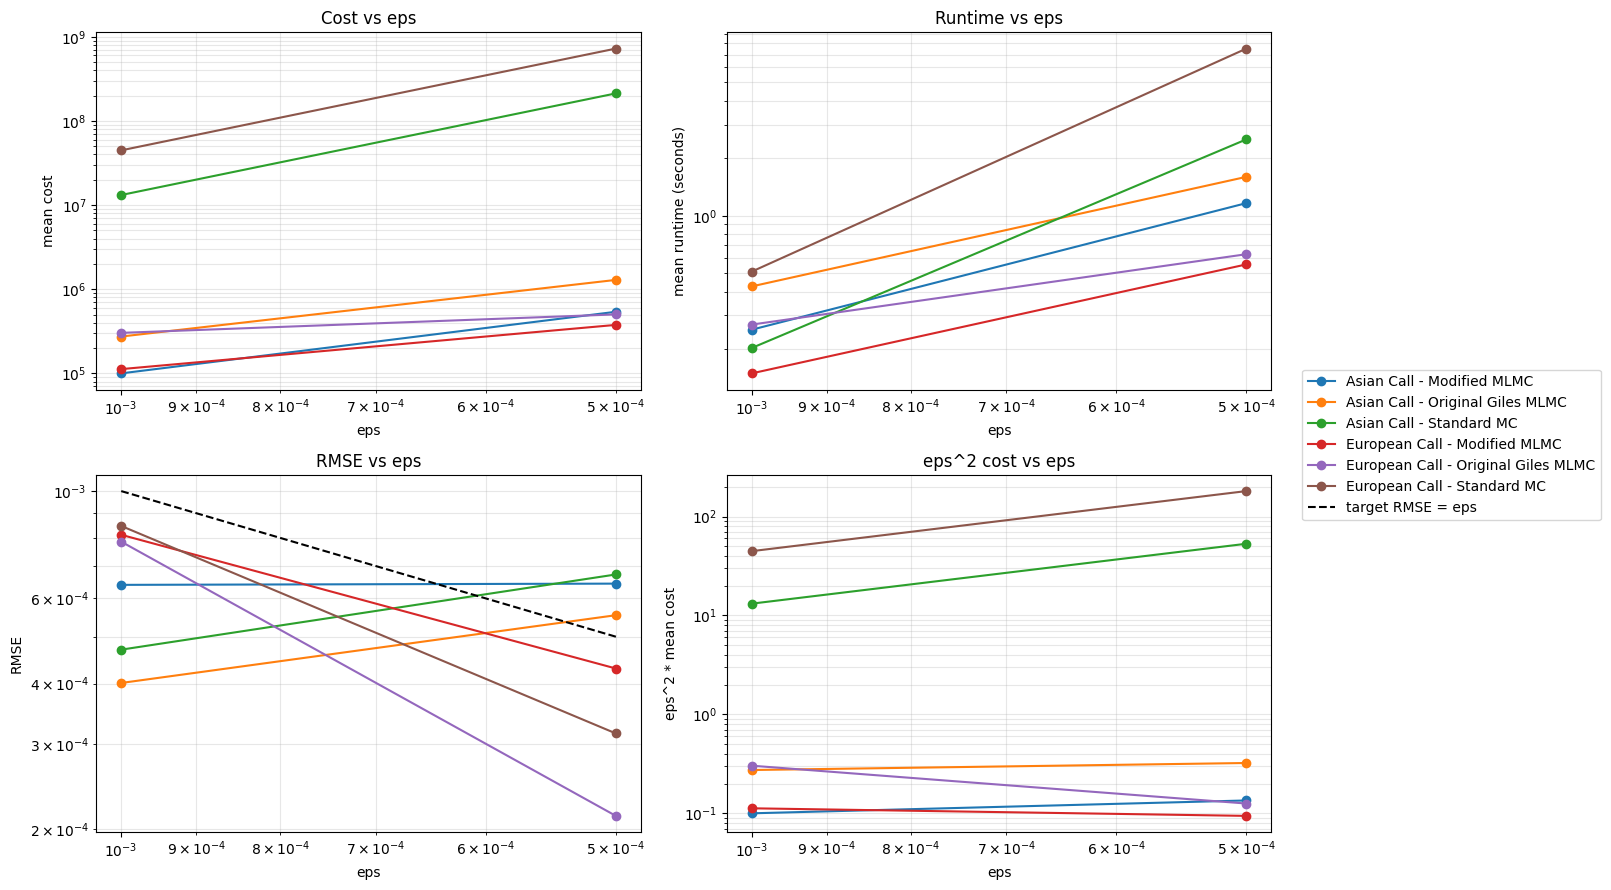

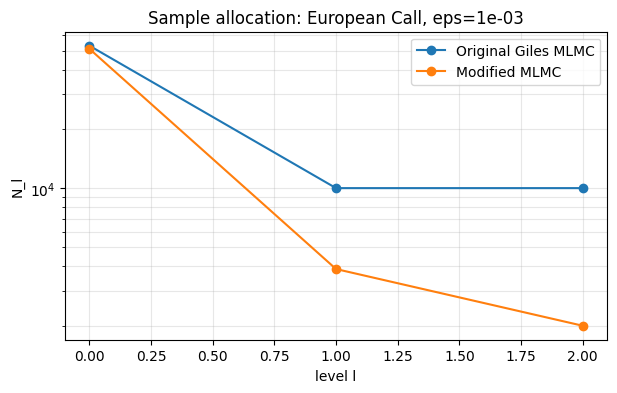

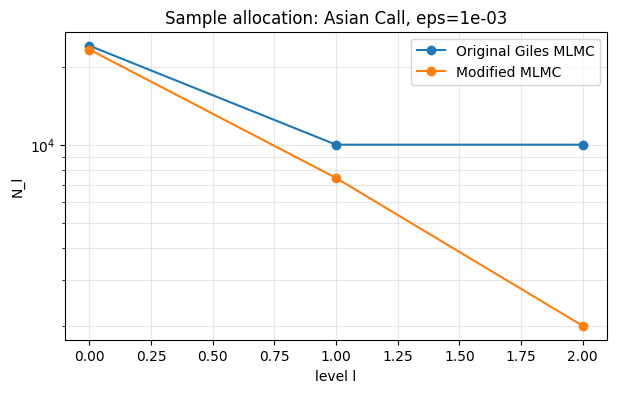

In [ ]:
# Final plots for the development run.
# Re-run this cell after increasing eps/reps/reference accuracy for final report figures.
if pd is not None:
    plot_final_comparisons(final_summary)
    plot_sample_allocations(final_rows, option="european", eps=FINAL_TEST_EPSILONS[0], rep=0)
    plot_sample_allocations(final_rows, option="asian", eps=FINAL_TEST_EPSILONS[0], rep=0)
else:
    print("pandas is unavailable; skipping final plots.")


# Ratio-Based MLMC Evaluation Metrics

To evaluate whether the modified MLMC method improves practical efficiency, we add ratio-based metrics comparing it directly against the original Giles MLMC method for the same option and target accuracy $\varepsilon$.

## Metrics

For each option and $\varepsilon$, define:

$$
\text{RMSE Ratio} = \frac{\text{RMSE}_{modified}}{\text{RMSE}_{original}},
$$

$$
\text{Cost Ratio} = \frac{\text{Cost}_{modified}}{\text{Cost}_{original}},
$$

$$
\text{Runtime Ratio} = \frac{\text{Runtime}_{modified}}{\text{Runtime}_{original}}.
$$

A ratio below 1 means the modified method is better on that metric. For RMSE, a value close to 1 means the two methods have comparable accuracy.

We also define an accuracy-cost efficiency score:

$$
\text{Efficiency} = \frac{1}{\text{RMSE}^2 \times \text{Cost}}.
$$

Higher efficiency is better. The corresponding ratio is

$$
\text{Efficiency Ratio} = \frac{\text{Efficiency}_{modified}}{\text{Efficiency}_{original}}.
$$

If this ratio is above 1, then the modified method achieves a better RMSE-cost tradeoff.

## Decision Rule

We classify modified MLMC as practically better when:

1. $\text{RMSE Ratio} \le 1.25$,
2. $\text{Cost Ratio} < 1$ or $\text{Runtime Ratio} < 1$,
3. $\text{Efficiency Ratio} > 1$.

We classify RMSE as comparable when:

$$
0.8 \le \text{RMSE Ratio} \le 1.25.
$$

This avoids claiming improvement when the modified method only reduces cost by sacrificing too much accuracy.


In [ ]:
def build_mlmc_ratio_table(summary):
    """Compare Modified MLMC against Original Giles MLMC by option and eps."""
    if pd is None:
        print("pandas is required for build_mlmc_ratio_table.")
        return None

    mlmc = summary[summary["method"].isin(["Original Giles MLMC", "Modified MLMC"])].copy()
    required = {"method", "option", "eps", "rmse", "mean_cost", "mean_runtime", "mean_price", "mean_std_error"}
    missing = required.difference(mlmc.columns)
    if missing:
        raise ValueError(f"summary is missing required columns: {sorted(missing)}")

    wide = mlmc.pivot(index=["option", "eps"], columns="method")

    rows = []
    for option, eps in wide.index:
        try:
            rmse_original = float(wide.loc[(option, eps), ("rmse", "Original Giles MLMC")])
            rmse_modified = float(wide.loc[(option, eps), ("rmse", "Modified MLMC")])
            cost_original = float(wide.loc[(option, eps), ("mean_cost", "Original Giles MLMC")])
            cost_modified = float(wide.loc[(option, eps), ("mean_cost", "Modified MLMC")])
            runtime_original = float(wide.loc[(option, eps), ("mean_runtime", "Original Giles MLMC")])
            runtime_modified = float(wide.loc[(option, eps), ("mean_runtime", "Modified MLMC")])
            price_original = float(wide.loc[(option, eps), ("mean_price", "Original Giles MLMC")])
            price_modified = float(wide.loc[(option, eps), ("mean_price", "Modified MLMC")])
            se_original = float(wide.loc[(option, eps), ("mean_std_error", "Original Giles MLMC")])
            se_modified = float(wide.loc[(option, eps), ("mean_std_error", "Modified MLMC")])
        except KeyError:
            continue

        efficiency_original = 1.0 / max(rmse_original**2 * cost_original, 1e-300)
        efficiency_modified = 1.0 / max(rmse_modified**2 * cost_modified, 1e-300)

        rmse_ratio = rmse_modified / rmse_original if rmse_original > 0 else np.nan
        cost_ratio = cost_modified / cost_original if cost_original > 0 else np.nan
        runtime_ratio = runtime_modified / runtime_original if runtime_original > 0 else np.nan
        efficiency_ratio = efficiency_modified / efficiency_original if efficiency_original > 0 else np.nan

        comparable_rmse = bool(0.8 <= rmse_ratio <= 1.25)
        modified_better = bool(
            (rmse_ratio <= 1.25)
            and ((cost_ratio < 1.0) or (runtime_ratio < 1.0))
            and (efficiency_ratio > 1.0)
        )

        eps_value = float(eps)

        rows.append({
            "Experiment": f"{option} | eps={eps_value:.0e}",
            "option": option,
            "eps": eps_value,
            "rmse_original": rmse_original,
            "rmse_modified": rmse_modified,
            "RMSE_Ratio": rmse_ratio,
            "cost_original": cost_original,
            "cost_modified": cost_modified,
            "Cost_Ratio": cost_ratio,
            "runtime_original": runtime_original,
            "runtime_modified": runtime_modified,
            "Runtime_Ratio": runtime_ratio,
            "efficiency_original": efficiency_original,
            "efficiency_modified": efficiency_modified,
            "Efficiency_Ratio": efficiency_ratio,
            "price_original": price_original,
            "price_modified": price_modified,
            "std_error_original": se_original,
            "std_error_modified": se_modified,
            "Comparable_RMSE": comparable_rmse,
            "Modified_Better": modified_better,
        })

    ratio_df = pd.DataFrame(rows)
    if ratio_df.empty:
        return ratio_df

    # Dynamic accuracy labels: smaller eps means a stricter, higher-accuracy target.
    # Labels are ranked within each option, so they adapt to whichever eps list is used.
    ratio_df["Accuracy_Rank"] = (
        ratio_df.groupby("option")["eps"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )
    ratio_df["Accuracy_Count"] = ratio_df.groupby("option")["eps"].transform("nunique").astype(int)

    def dynamic_accuracy_label(row):
        if row["Accuracy_Count"] == 1:
            return "only accuracy target"
        if row["Accuracy_Rank"] == 1:
            return "highest accuracy target"
        if row["Accuracy_Rank"] == row["Accuracy_Count"]:
            return "lowest accuracy target"
        return f"intermediate accuracy target {row['Accuracy_Rank']}/{row['Accuracy_Count']}"

    ratio_df["Accuracy_Level"] = ratio_df.apply(dynamic_accuracy_label, axis=1)
    return ratio_df.sort_values(["option", "eps"], ascending=[True, False]).reset_index(drop=True)


def plot_mlmc_ratio_metrics(ratio_df) -> None:
    """Plot RMSE, cost/runtime, and efficiency ratios for Modified vs Original MLMC."""
    if pd is None:
        print("pandas is required for plot_mlmc_ratio_metrics.")
        return
    if ratio_df is None or ratio_df.empty:
        print("ratio_df is empty; run build_mlmc_ratio_table first.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for option, option_df in ratio_df.groupby("option"):
        ordered = option_df.sort_values("eps")
        axes[0].semilogx(ordered["eps"], ordered["RMSE_Ratio"], marker="o", label=option)
        axes[1].semilogx(ordered["eps"], ordered["Cost_Ratio"], marker="o", label=f"{option} cost")
        axes[1].semilogx(ordered["eps"], ordered["Runtime_Ratio"], marker="s", linestyle="--", label=f"{option} runtime")
        axes[2].semilogx(ordered["eps"], ordered["Efficiency_Ratio"], marker="o", label=option)

    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[0].axhline(1.25, color="red", linestyle=":", linewidth=1)
    axes[0].axhline(0.8, color="red", linestyle=":", linewidth=1)
    axes[0].set_title("RMSE Ratio")
    axes[0].set_ylabel("Modified / Original")

    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Cost and Runtime Ratios")
    axes[1].set_ylabel("Modified / Original")

    axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title("Efficiency Ratio")
    axes[2].set_ylabel("Modified / Original")

    for ax in axes:
        ax.invert_xaxis()
        ax.set_xlabel("eps")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


def print_ratio_conclusion(ratio_df) -> None:
    """Print a compact interpretation of the ratio table."""
    if ratio_df is None or len(ratio_df) == 0:
        print("No ratio results available.")
        return

    for _, row in ratio_df.iterrows():
        status = "better" if row["Modified_Better"] else "not clearly better"
        comparable = "comparable" if row["Comparable_RMSE"] else "not comparable"
        print(
            f"{row.get('Experiment', row['option'])}: Modified is {status}; "
            f"RMSE is {comparable}. "
            f"RMSE ratio={row['RMSE_Ratio']:.3f}, "
            f"cost ratio={row['Cost_Ratio']:.3f}, "
            f"runtime ratio={row['Runtime_Ratio']:.3f}, "
            f"efficiency ratio={row['Efficiency_Ratio']:.3f}."
        )


,Experiment,option,eps,Accuracy_Level,Accuracy_Rank,Accuracy_Count,rmse_original,rmse_modified,RMSE_Ratio,cost_original,cost_modified,Cost_Ratio,runtime_original,runtime_modified,Runtime_Ratio,efficiency_original,efficiency_modified,Efficiency_Ratio,Comparable_RMSE,Modified_Better
0,Asian Call | eps=1e-03,Asian Call,0.0010,lowest accuracy target,2,2,0.000401,0.000640,1.595164,2.741543e+05,100082.000000,0.365057,0.426097,0.252682,0.593016,22.664044,24.398661,1.076536,False,False
1,Asian Call | eps=5e-04,Asian Call,0.0005,highest accuracy target,1,2,0.000554,0.000644,1.162159,1.291193e+06,539937.000000,0.418169,1.599275,1.164712,0.728275,2.524382,4.469636,1.770586,True,True
2,European Call | eps=1e-03,European Call,0.0010,lowest accuracy target,2,2,0.000786,0.000812,1.033203,3.032183e+05,112473.333333,0.370932,0.268759,0.149150,0.554961,5.336664,13.477347,2.525426,True,True
3,European Call | eps=5e-04,European Call,0.0005,highest accuracy target,1,2,0.000213,0.000430,2.016607,5.025623e+05,377101.666667,0.750358,0.628572,0.555888,0.884368,43.809541,14.356804,0.327710,False,False


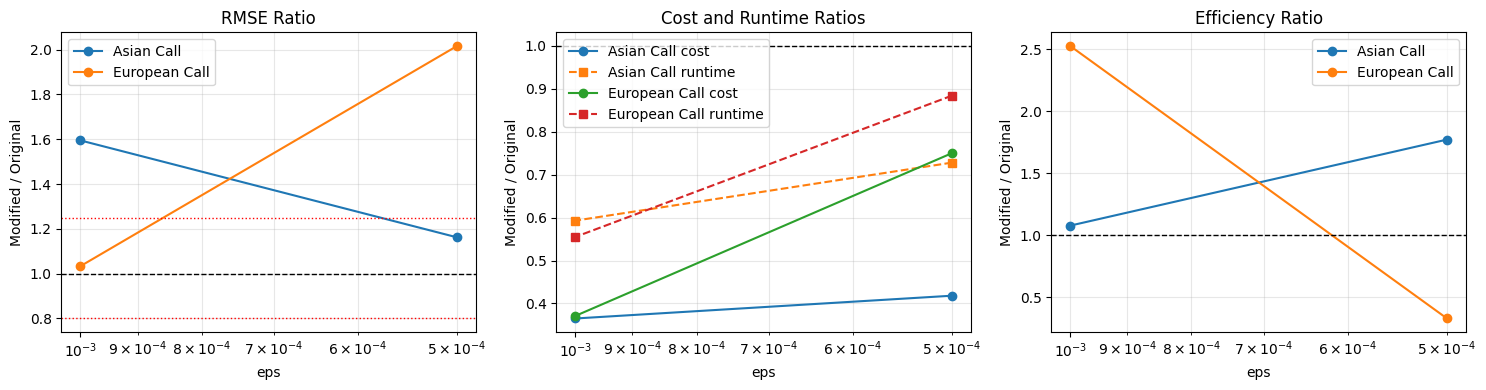

Asian Call | eps=1e-03: Modified is not clearly better; RMSE is not comparable. RMSE ratio=1.595, cost ratio=0.365, runtime ratio=0.593, efficiency ratio=1.077.
Asian Call | eps=5e-04: Modified is better; RMSE is comparable. RMSE ratio=1.162, cost ratio=0.418, runtime ratio=0.728, efficiency ratio=1.771.
European Call | eps=1e-03: Modified is better; RMSE is comparable. RMSE ratio=1.033, cost ratio=0.371, runtime ratio=0.555, efficiency ratio=2.525.
European Call | eps=5e-04: Modified is not clearly better; RMSE is not comparable. RMSE ratio=2.017, cost ratio=0.750, runtime ratio=0.884, efficiency ratio=0.328.


In [ ]:
# Build and display Modified-vs-Original MLMC ratio metrics.
if pd is not None:
    mlmc_ratio_df = build_mlmc_ratio_table(final_summary)
    display(mlmc_ratio_df[[
        "Experiment", "option", "eps", "Accuracy_Level", "Accuracy_Rank", "Accuracy_Count",
        "rmse_original", "rmse_modified", "RMSE_Ratio",
        "cost_original", "cost_modified", "Cost_Ratio",
        "runtime_original", "runtime_modified", "Runtime_Ratio",
        "efficiency_original", "efficiency_modified", "Efficiency_Ratio",
        "Comparable_RMSE", "Modified_Better",
    ]])
    plot_mlmc_ratio_metrics(mlmc_ratio_df)
    print_ratio_conclusion(mlmc_ratio_df)
else:
    print("pandas is unavailable; ratio table was not built.")


In [ ]:
mlmc_ratio_df.head(50)


,Experiment,option,eps,rmse_original,rmse_modified,RMSE_Ratio,cost_original,cost_modified,Cost_Ratio,runtime_original,...,Efficiency_Ratio,price_original,price_modified,std_error_original,std_error_modified,Comparable_RMSE,Modified_Better,Accuracy_Rank,Accuracy_Count,Accuracy_Level
0,Asian Call | eps=1e-03,Asian Call,0.0010,0.000401,0.000640,1.595164,2.741543e+05,100082.000000,0.365057,0.426097,...,1.076536,0.057940,0.057690,0.000582,0.000678,False,False,2,2,lowest accuracy target
1,Asian Call | eps=5e-04,Asian Call,0.0005,0.000554,0.000644,1.162159,1.291193e+06,539937.000000,0.418169,1.599275,...,1.770586,0.057717,0.057690,0.000310,0.000345,True,True,1,2,highest accuracy target
2,European Call | eps=1e-03,European Call,0.0010,0.000786,0.000812,1.033203,3.032183e+05,112473.333333,0.370932,0.268759,...,2.525426,0.104988,0.104504,0.000598,0.000684,True,True,2,2,lowest accuracy target
3,European Call | eps=5e-04,European Call,0.0005,0.000213,0.000430,2.016607,5.025623e+05,377101.666667,0.750358,0.628572,...,0.327710,0.104682,0.104105,0.000333,0.000357,False,False,1,2,highest accuracy target
